# Goal-Conditioned DQN on Unity ML-Agents GridWorld

A DQN written from scratch against the Unity ML-Agents low-level Python API.

**The task.** The grid contains two target types. At the start of each episode one
is selected at random, and a *goal signal* observation tells the agent which one to
reach. Touching the indicated target pays +1, the other pays -1, and each step costs
0.01. Because the same camera image maps to different optimal actions depending on
the signal, the value function is Q(s, a, g) rather than Q(s, a) — a universal value
function approximator in the sense of Schaul et al.

**Result.** Solved at 18,000 environment steps. Greedy evaluation averages 0.97
against a random baseline of -0.31.

**The interesting part is how it failed first.** An earlier version sat at exactly
chance for 50,000 steps. The section at the bottom of this notebook records the
diagnosis, two hypotheses that turned out to be wrong, and the controlled ablation
that identified the actual cause.

In [1]:
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple, defaultdict
import matplotlib.pyplot as plt
%matplotlib inline

import mlagents_envs
from mlagents_envs.environment import UnityEnvironment, ActionTuple
from mlagents_envs.side_channel.engine_configuration_channel import EngineConfigurationChannel


In [2]:
BUFFER_SIZE = int(2e5)  # replay buffer size
BATCH_SIZE = 64         # minibatch size
GAMMA = 0.9            # discount factor
TAU = 1e-3              # for soft update of target parameters
LR = 1e-4               # learning rate 
UPDATE_EVERY = 4        # how often to update the network

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
channel = EngineConfigurationChannel()
env = UnityEnvironment(file_name=None, seed=0, side_channels=[channel]) 
#open the scenes on editor and press play

#faster simulation speed
channel.set_configuration_parameters(time_scale=20.0)
env.reset()

In [4]:
# We will only consider the first Behavior
behavior_name = list(env.behavior_specs)[0]
print(f"Name of the behavior : {behavior_name}")
spec = env.behavior_specs[behavior_name]

Name of the behavior : GridWorld?team=0


## Random baseline

Worth measuring before anything else. Without it, "average return -0.2" is
uninterpretable — it could mean the agent is far better than chance or slightly worse,
and there is no way to tell from the number alone.

It also needs enough episodes to mean something, and that requirement is larger than
it looks.

**The noise model.** Returns here are dominated by a single binary outcome: the agent
reaches the correct target (+1) or the wrong one (-1), with the 0.01 step cost a
rounding error on top. So the per-episode return is a shifted Bernoulli with

    sd = 2 * sqrt(p * (1 - p))

where p is the success rate. That peaks at 1.0 when p = 0.5 and shrinks towards either
extreme:

| success rate p | mean return | sd | SE at n=10 | SE at n=50 | SE at n=100 |
|---|---|---|---|---|---|
| 0.31 (random) | -0.38 | 0.93 | 0.29 | 0.13 | 0.09 |
| 0.48 (chance between targets) | -0.04 | 1.00 | 0.32 | 0.14 | 0.10 |
| 0.90 | 0.80 | 0.60 | 0.19 | 0.09 | 0.06 |
| 0.98 | 0.96 | 0.28 | 0.09 | 0.04 | 0.03 |

Note the shape: variance is maximal in the *middle* of the range, so a mediocre agent
is harder to measure than a good one — backwards from where precision is needed while
debugging. An agent stuck at 48% success sits exactly at the worst point.

**This is not hypothetical.** The random baseline has been run four times at different
sample sizes across sessions:

| episodes | measured mean |
|---|---|
| 10 | -0.252 |
| 50 | -0.308 |
| 50 | -0.237 (the run below) |
| 100 | -0.387 |

All four are consistent with a single underlying value — the spread is ordinary
sampling noise, and the two 50-episode runs differ by 0.07 against a standard error
of about 0.13. But the 10-episode figure carries a 95% interval of roughly
[-0.85, +0.35], which admits a *positive* mean return. Ten episodes cannot distinguish
a random policy from one that is learning.

**Caveat on the derived success rates.** The p values above are inferred by inverting
`mean = 2p - 1`, which assumes exactly two outcomes. A random policy is where that
assumption is weakest: an episode that times out without reaching any target returns
only accumulated step cost, a third outcome that drags the mean down and makes the
inverted p an underestimate. Classifying terminal rewards directly would settle it.

In [5]:
##random agent

all_rewards = []
for episode in range(50):
  env.reset()
  decision_steps, terminal_steps = env.get_steps(behavior_name)
  tracked_agent = -1 # -1 indicates not yet tracking
  done = False # For the tracked_agent
  episode_rewards = 0 # For the tracked_agent
  while not done:
    # Track the first agent we see if not tracking
    # Note : len(decision_steps) = [number of agents that requested a decision]
    if tracked_agent == -1 and len(decision_steps) >= 1:
      tracked_agent = decision_steps.agent_id[0]

    # Generate an action for all agents
    action = spec.action_spec.random_action(len(decision_steps))

    # Set the actions
    env.set_actions(behavior_name, action)

    # Move the simulation forward
    env.step()

    # Get the new simulation results
    decision_steps, terminal_steps = env.get_steps(behavior_name)
    if tracked_agent in decision_steps: # The agent requested a decision
      episode_rewards += decision_steps[tracked_agent].reward
    if tracked_agent in terminal_steps: # The agent terminated its episode
      episode_rewards += terminal_steps[tracked_agent].reward
      done = True
      all_rewards.append(episode_rewards)
      print(f"\rTotal rewards for episode {episode} is {episode_rewards:.4f}", end="")

print("\nAverage rewards:", np.mean(all_rewards))


Total rewards for episode 49 is -1.1000
Average rewards: -0.2367999942600727


## Reading the observation specs

Never index observations by position. The order follows the sensor order on the
Unity agent and changes if anyone reorders components. Select by shape or by
`observation_type` instead.

Two things to note in the output below:

- The camera arrives as **(3, 64, 84)** — already channels-first, so no permute is
  needed before `Conv2d`. Note it is *not* square; 84x84 is a convention inherited
  from the Atari DQN paper, not a requirement. Resizing to square here would only
  distort the aspect ratio and waste compute.
- The vector sensor is tagged `GOAL_SIGNAL`. For `mlagents-learn` that tag is
  functional — the trainer routes it through a conditioning mechanism. For a custom
  Python loop it is metadata; the array arrives in `obs` like any other and what to
  do with it is a design decision.

In [6]:
print("Total environment specs:", len(spec.observation_specs))

Total environment specs: 2


In [7]:
for i, s in enumerate(spec.observation_specs):
    print(i, s.name, s.shape, s.observation_type, s.dimension_property)

0 CameraSensor (3, 64, 84) ObservationType.DEFAULT (<DimensionProperty.NONE: 1>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>)
1 VectorSensor (2,) ObservationType.GOAL_SIGNAL (<DimensionProperty.NONE: 1>,)


Rendering the observation is a cheap sanity check that the pipeline is intact.
**RGB is required here**, unlike Pong: the two target types are distinguished
primarily by colour, so converting to grayscale can collapse them and make the goal
signal unusable. Frame stacking, on the other hand, is unnecessary — the grid is
fully observable from a single image and nothing has momentum.

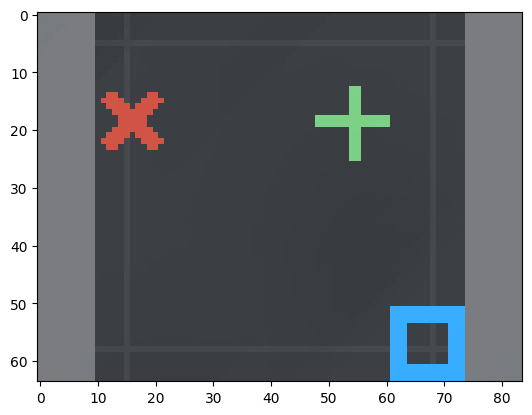

In [8]:
plt.imshow(np.transpose(decision_steps.obs[0][0],axes=(1,2,0)))
plt.show()

In [9]:
decision_steps.obs[0][0].min(), decision_steps.obs[0][0].max()

(0.21568628, 1.0)

The second observation is goal signal. this observation describes what the agent is being asked to do, not what it's seeing.

## Network

Two conditioning schemes were tried, and **both work** once the discount factor is
right (see the findings section at the bottom):

1. **Head concatenation** (below) — run the conv stack on the image, then
   concatenate the goal one-hot onto the flattened features. Simple, but the goal
   contributes only 2 of 898 inputs to the first linear layer.
2. **Input-channel broadcast** (next cell, commented) — tile the goal one-hot
   spatially and feed it as extra input channels, so the convolution itself is
   goal-aware from the first layer.

The dummy forward pass that computes `n_flat` matters: hardcoding a flatten size
breaks silently on any other resolution.

In [10]:
class GoalConditionedQNet(nn.Module):
    def __init__(self, in_ch, goal_dim, n_actions, seed ,feat_dim=256):
        super().__init__()
        self.seed = torch.manual_seed(seed)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 16, 8, 4), nn.ReLU(),
            nn.Conv2d(16, 32, 4, 2), nn.ReLU(),
            nn.Conv2d(32, 32, 3, 1), nn.ReLU(), 
            nn.Flatten(),
        )
        with torch.no_grad():
            n_flat = self.conv(torch.zeros(1, in_ch, 64, 84)).shape[1]
        self.head = nn.Sequential(
            nn.Linear(n_flat + goal_dim, feat_dim), nn.ReLU(),
            nn.Linear(feat_dim, n_actions),
        )

    def forward(self, img, goal):
        conv_out = self.conv(img)
        cat = torch.cat([conv_out, goal], dim=1)
        out = self.head(cat)
        return out

In [11]:
## This also works fine

# class GoalConditionedQNet(nn.Module):
#     def __init__(self, in_ch, goal_dim, n_actions, seed ,feat_dim=256):
#         super().__init__()
#         self.seed = torch.manual_seed(seed)
#         self.conv = nn.Sequential(
#             nn.Conv2d(in_ch + goal_dim, 16, 8, 4), nn.ReLU(),
#             nn.Conv2d(16, 32, 4, 2), nn.ReLU(),
#             nn.Conv2d(32, 32, 3, 1), nn.ReLU(), 
#             nn.Flatten(),
#         )
#         with torch.no_grad():
#             n_flat = self.conv(torch.zeros(1, in_ch + goal_dim, 64, 84)).shape[1]
#         self.head = nn.Sequential(
#             nn.Linear(n_flat, feat_dim), nn.ReLU(),
#             nn.Linear(feat_dim, n_actions),
#         )

#     def forward(self, img, goal):
#         B, _, H, W = img.shape
#         g = goal.view(B, -1, 1, 1).expand(B, goal.shape[1], H, W)
#         conv_out = self.conv(torch.cat([img, g], dim=1))
#         out = self.head(conv_out)
#         return out

## Replay memory

Observations arrive as float32 in [0, 1]. Storing them that way costs 4x more than
necessary, so frames are scaled to uint8 on the way in and divided by 255 on the way
out. At 2e5 transitions with both `state` and `next_state`, that is roughly 6.5 GB
instead of 26 GB.

The buffer also carries `mask_next` — the action mask at the *next* state. This is
needed because the mask has to be applied in two places, not one (see `learn`).

In [12]:
class ReplayBuffer:
    """Fixed-size buffer to store experience tuples."""

    def __init__(self, buffer_size, batch_size, seed):
        """Initialize a ReplayBuffer object.

        Params
        ======
            buffer_size (int): maximum size of buffer
            batch_size (int): size of each training batch
            seed (int): random seed
        """
        self.memory = deque(maxlen=buffer_size)  
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "goal", "action",\
                        "reward", "next_state", "next_goal", "done", "mask_next"])
        self.seed = random.seed(seed)
    
    def add(self, state, goal, action, reward, next_state, next_goal, done, mask_next):
        """Add a new experience to memory."""
        state = (state*255).astype(np.uint8)
        next_state = (next_state*255).astype(np.uint8)
        e = self.experience(state, goal ,action, reward, next_state, next_goal, done, mask_next)
        self.memory.append(e)
    
    def sample(self):
        """Randomly sample a batch of experiences from memory."""
        experiences = random.sample(self.memory, k=self.batch_size)

        states = torch.from_numpy(np.array([e.state/255.0 for e in experiences if e is not None])).float().to(device)
        goals = torch.from_numpy(np.array([e.goal for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.array([e.action for e in experiences if e is not None])).long().to(device).unsqueeze(1)
        rewards = torch.from_numpy(np.array([e.reward for e in experiences if e is not None])).float().to(device).unsqueeze(1)
        next_states = torch.from_numpy(np.array([e.next_state/255.0 for e in experiences if e is not None])).float().to(device)
        next_goals = torch.from_numpy(np.array([e.next_goal for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.array([e.done for e in experiences if e is not None]).astype(np.uint8)).float().to(device).unsqueeze(1)
        mask_next = torch.from_numpy(np.array([e.mask_next for e in experiences if e is not None]).astype(np.uint8)).bool().to(device)
  
        return (states, goals, actions, rewards, next_states, next_goals, dones, mask_next)

    def __len__(self):
        """Return the current size of internal memory."""
        return len(self.memory)

## Agent

Two details that are easy to get wrong:

**Masking is applied to both the policy and the target.** Applying it only at action
selection is the common mistake: the target's `max` would then bootstrap off an
illegal action's Q-value, which is never corrected by experience because that action
is never taken and never appears in a loss term. Those values drift freely and
inflate every target. `-1e9` is used rather than `-inf` to avoid NaNs if a row is
ever fully masked.

**Exploration samples uniformly over legal actions**, per agent rather than per
batch. With several agents in the scene, one shared coin flip would make all of them
explore or exploit together, correlating exactly the transitions replay exists to
decorrelate.

In [13]:
class Agent():
    """Interacts with and learns from the environment."""

    def __init__(self,in_ch, goal_dim, n_actions, seed):
        """Initialize an Agent object.
        
        Params
        ======
            state_size (int): dimension of each state
            action_size (int): dimension of each action
            seed (int): random seed
        """
        self.in_ch = in_ch
        self.goal_dim = goal_dim
        self.n_actions = n_actions
        self.seed = random.seed(seed)
        self.losses = []
        self.q_log = []

        # Q-Network
        self.qnetwork_local = GoalConditionedQNet(in_ch, goal_dim, n_actions, seed).to(device)
        self.qnetwork_target = GoalConditionedQNet(in_ch, goal_dim, n_actions, seed).to(device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=LR)

        # Replay memory
        self.memory = ReplayBuffer(BUFFER_SIZE, BATCH_SIZE, seed)
        # Initialize time step (for updating every UPDATE_EVERY steps)
        self.t_step = 0
    
    def step(self, state, goal, action, reward, next_state, next_goal ,done, mask_next):
        # Save experience in replay memory
        self.memory.add(state, goal, action, reward, next_state, next_goal, done, mask_next)
        
        # Learn every UPDATE_EVERY time steps.
        self.t_step = (self.t_step + 1) % UPDATE_EVERY
        if self.t_step == 0 and len(self.memory) > 5000:
            # If enough samples are available in memory, get random subset and learn
            experiences = self.memory.sample()
            self.learn(experiences, GAMMA)

    def act(self, obs, goal, mask, eps=0.):
        """ obs: (n, state_size) float32,(n: number of agents)
            goal: (n, goal_size) float32
            mask: (n, action_size) bool, True = illegal
            Note: Mask is true when action is unavailable  
        """
                
        obs_t  = torch.as_tensor(obs,  dtype=torch.float32, device=device)
        goal_t = torch.as_tensor(goal,  dtype=torch.float32, device=device)
        mask_t = torch.as_tensor(mask, dtype=torch.bool,    device=device)

        with torch.no_grad():
            #fill q values of illegal actions with -1e9, so that they are never selected
            q = self.qnetwork_local(obs_t, goal_t).masked_fill(mask_t, -1e9)

        greedy  = q.argmax(dim=1)
        #select random action from legal actions. The probability of selecting each legal action is equal.
        # Probability of selecting illegal actions is 0.

        rand    = torch.multinomial((~mask_t).float(), 1).squeeze(1)
        explore = torch.rand(len(obs), device=device) < eps

        return torch.where(explore, rand, greedy).cpu().numpy()

    def learn(self, experiences, gamma):
        """Update value parameters using given batch of experience tuples.

        Params
        ======
            experiences (Tuple[torch.Tensor]): tuple of (s, g, a, r, s', g', done) tuples 
            gamma (float): discount factor
        """
        states, goals, actions, rewards, next_states, next_goals, dones, next_masks = experiences

        ## compute and minimize the loss
        self.optimizer.zero_grad()
        out = self.qnetwork_local(states, goals)
        Q_curr = torch.gather(out, dim =-1, index = actions)
        with torch.no_grad():
            q_next = self.qnetwork_target(next_states, next_goals).masked_fill(next_masks, -1e9)
            Q_next = q_next.max(dim=-1, keepdim=True)[0]
            target = rewards + (gamma*Q_next*(1-dones)) 
                   
        loss = F.huber_loss(Q_curr, target)
        self.losses.append(loss.item())
        self.q_log.append(Q_curr.detach().mean().item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.qnetwork_local.parameters(), max_norm=10.0)
        self.optimizer.step()


        # ------------------- update target network ------------------- #
        self.soft_update(self.qnetwork_local, self.qnetwork_target, TAU)                     

    def soft_update(self, local_model, target_model, tau):
        """Soft update model parameters.
        θ_target = τ*θ_local + (1 - τ)*θ_target

        Params
        ======
            local_model (PyTorch model): weights will be copied from
            target_model (PyTorch model): weights will be copied to
            tau (float): interpolation parameter 
        """
        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau*local_param.data + (1.0-tau)*target_param.data)


In [14]:
def evaluate(env, agent, n_episodes=50):
    all_rewards = []
    for episode in range(n_episodes):
        env.reset()
        decision_steps, terminal_steps = env.get_steps(behavior_name)
        tracked_agent = -1 # -1 indicates not yet tracking
        done = False # For the tracked_agent
        episode_rewards = 0 # For the tracked_agent
        while not done:
            # Track the first agent we see if not tracking
            # Note : len(decision_steps) = [number of agents that requested a decision]
            if tracked_agent == -1 and len(decision_steps) >= 1:
              tracked_agent = decision_steps.agent_id[0]
        
            # Generate an action for all agents
            decision_mask = decision_steps.action_mask[0] if decision_steps.action_mask is not None else np.zeros((len(decision_steps), action_size), dtype=bool)
            actions = agent.act(decision_steps.obs[0], decision_steps.obs[1],decision_mask)
        
            # Set the actions
            env.set_actions(behavior_name, ActionTuple(discrete=actions.reshape(-1, 1).astype(np.int32)))
        
            # Move the simulation forward
            env.step()
        
            # Get the new simulation results
            decision_steps, terminal_steps = env.get_steps(behavior_name)
            if tracked_agent in decision_steps: # The agent requested a decision
              episode_rewards += decision_steps[tracked_agent].reward
            if tracked_agent in terminal_steps: # The agent terminated its episode
              episode_rewards += terminal_steps[tracked_agent].reward
              done = True
              all_rewards.append(episode_rewards)
                      
    return np.mean(all_rewards) 

## Training loop

The ML-Agents stepping model differs from Gym in a way that shapes this whole
function: `env.step()` takes no action and returns no observation. It advances the
simulation until some agent needs a decision, and the reward and next state for an
action only arrive on that agent's *next* decision. The `pending` dict holds the
half-transition until then.

Details that are easy to get wrong:

- **`done = not ts.interrupted`.** A time-limit truncation is not a terminal state and
  must still bootstrap. Treating timeouts as terminals biases every value estimate
  downward.
- **`agent_id_to_index`.** Row order in the observation array is not agent id and
  changes as agents terminate and respawn. Mixing them up scrambles transitions in a
  way that still trains, just badly.
- **ML-Agents issues a new agent id when an episode ends.** So an agent appears in
  `terminal_steps` under its old id and in `decision_steps` under a new one on the
  same iteration. Popping from `pending` on termination and repopulating on decision
  handles this — and the `if agent_id in pending` guard on both branches is what makes
  the gap harmless, since the first decision of an episode has no prior action to
  complete. The `ep_disc` / `ep_k` pops matter for the same reason: without them the
  dicts would grow for the whole run.

**Discounted returns are logged alongside plain ones.** Q(s, a) estimates the
*discounted* return, so comparing mean Q against an undiscounted episode return is a
category error — at gamma 0.9 an agent reaching the target in three steps collects
0.97 undiscounted but only 0.78 discounted. `ep_disc` accumulates
`GAMMA**ep_k * reward` per agent, with `ep_k` counting only rewards that follow an
action actually taken. This turned out to be the measurement that resolved the whole
investigation below.

Evaluation is greedy (eps = 0) and gated behind a training-window threshold, because
the training average includes exploration episodes and cannot reach 0.9 while eps is
still meaningful.

In [16]:
def train(agent, n_steps=20_000, eps_start=1.0, eps_end=0.05, eps_decay=.9999):
    pending    = {}                      # agent_id -> ((state, goal), action)
    ep_return  = defaultdict(float)
    scores, window = [], deque(maxlen=100)
    eps = eps_start
    #discouned returns
    ep_disc = defaultdict(float)   # discounted return so far this episode
    ep_k    = defaultdict(int)     # how many rewards this agent has received
    disc_window = deque(maxlen=100)

    env.reset()

    for t in range(n_steps):
        decision_steps, terminal_steps = env.get_steps(behavior_name)

        # --- agents whose episode just ended ---
        for agent_id in terminal_steps:
            ts = terminal_steps[agent_id]
            if agent_id in pending:
                #remove the s,a pair for the agent whose episode just ended
                (s,g), a = pending.pop(agent_id)
                done = not ts.interrupted          # timeout still bootstraps
                agent.step(s, g, a, ts.reward, ts.obs[0], ts.obs[1], done,
                           np.zeros(action_size, dtype=bool))
                ep_disc[agent_id] +=(GAMMA**ep_k[agent_id])*ts.reward

            
            disc_window.append(ep_disc[agent_id])
            ep_disc.pop(agent_id, None)
            ep_k.pop(agent_id, None)    

            ep_return[agent_id] += ts.reward
            window.append(ep_return[agent_id])
            scores.append(ep_return[agent_id])
            ep_return[agent_id] = 0.0

        # --- agents needing an action ---
        if len(decision_steps) > 0:
            obs = decision_steps.obs[0]
            goals = decision_steps.obs[1]
            n   = len(decision_steps)
            mask = (np.zeros((n, action_size), dtype=bool)
                    if decision_steps.action_mask is None
                    else decision_steps.action_mask[0])

            #actions for all agents which need a decision
            actions = agent.act(obs, goals, mask, eps)

            for agent_id in decision_steps:
                i = decision_steps.agent_id_to_index[agent_id]
                r = decision_steps[agent_id].reward
                if agent_id in pending:
                    (s,g), a = pending[agent_id]
                    agent.step(s, g, a, r, obs[i], goals[i], False, mask[i])
                    ep_disc[agent_id] += (GAMMA ** ep_k[agent_id]) * r
                    ep_k[agent_id] += 1

                ep_return[agent_id] += r
                pending[agent_id] = ((obs[i].copy(), goals[i].copy()), actions[i])

            env.set_actions(behavior_name,
                            ActionTuple(discrete=actions.reshape(-1, 1).astype(np.int32)))

        env.step()
        eps = max(eps_end, eps_decay * eps)


        if (t+1) % 1000 == 0 and window:
            print(f"step {t+1}\teps {eps:.3f}\tavg return {np.mean(window):.3f}\tavg discounted returns {np.mean(disc_window):.3f}")

        if ((t+1) %1000==0) and (np.mean(window)>0.5):
            mean_scores = evaluate(env,agent)
            if mean_scores>0.9:
                print(f"\nEnvironment solved in {t+1} steps!\tAverage Return: {mean_scores:.3f}\tavg discounted returns {np.mean(disc_window)})")
                checkpoint = {
                            'epoch': t,
                            'eps': eps,
                            'eps_decay': eps_decay,
                            'model_state_dict': agent.qnetwork_local.state_dict(),
                            'optimizer_state_dict': agent.optimizer.state_dict(),
                        }

                torch.save(checkpoint, 'checkpoint.pth')
                break

    return scores

In [17]:
action_size = spec.action_spec.discrete_branches[0]
goal_dim = spec.observation_specs[1].shape[0]
agent = Agent(in_ch=3,goal_dim= goal_dim, n_actions= action_size, seed=0)

In [18]:
scores = train(agent)

step 1000	eps 0.905	avg return -0.200	avg discounted returns -0.029
step 2000	eps 0.819	avg return -0.252	avg discounted returns -0.048
step 3000	eps 0.741	avg return -0.316	avg discounted returns -0.123
step 4000	eps 0.670	avg return -0.044	avg discounted returns -0.011
step 5000	eps 0.607	avg return 0.212	avg discounted returns 0.110
step 6000	eps 0.549	avg return 0.492	avg discounted returns 0.290
step 7000	eps 0.497	avg return 0.601	avg discounted returns 0.367
step 8000	eps 0.449	avg return 0.647	avg discounted returns 0.372
step 9000	eps 0.407	avg return 0.736	avg discounted returns 0.387
step 10000	eps 0.368	avg return 0.742	avg discounted returns 0.408
step 11000	eps 0.333	avg return 0.826	avg discounted returns 0.504
step 12000	eps 0.301	avg return 0.785	avg discounted returns 0.494
step 13000	eps 0.273	avg return 0.831	avg discounted returns 0.567
step 14000	eps 0.247	avg return 0.891	avg discounted returns 0.619
step 15000	eps 0.223	avg return 0.894	avg discounted returns 0.

## Findings: a value function that diverged

### What happened

With **gamma = 0.99** this agent never solved the task. With **gamma = 0.9**, and no
other change, it solves in 15,000 steps. Every mechanical part of the DQN was correct
in both cases — transition assembly, reward attribution across the decision gap,
terminal handling, masking in both places. The bug was never in the code.

The gamma 0.99 runs failed in two different ways across attempts:

- **Flat at chance.** 50,000 steps at roughly -0.2 average return, with a success rate
  of 47.2% over the first 5k episodes and 47.9% over the last 5k. Against a ~31%
  random baseline the agent had clearly learned to reach *a* target reliably — it just
  picked the right one no more often than a coin flip, and never improved.
- **Rise then collapse.** Return climbs to 0.56, then falls to -0.51 by step 20,000.

### The environment has a hard ceiling on Q

The best achievable discounted return is reaching the correct target on the first
step: `-0.01 + 1 = 0.99`. That bound holds for every gamma and every policy. Any
Q-value above 0.99 is not optimism — it is provably wrong.

| | mean Q (last 1k) | max Q | mean discounted return | ceiling | gap |
|---|---|---|---|---|---|
| gamma = 0.9 | 0.693 | 0.782 | 0.622 | 0.99 | **+0.07** |
| gamma = 0.99 | 1.256 | 1.325 | -0.323 | 0.99 | **+1.58** |

At gamma 0.9 the value function is well calibrated. The residual +0.07 is partly
expected rather than error: mean Q averages over buffer states at every distance,
while the discounted return is measured from episode starts, which sit further from
the target. A correctly calibrated agent should show Q slightly above.

At gamma 0.99 mean Q sits **27% above a bound the environment makes impossible**, and
the loss is *lower* than the working run (0.00085 against 0.0013). The network is
fitting a self-consistent fantasy with great precision. The rise-then-collapse is what
runaway inflation looks like from the outside: estimates grow, the greedy policy
starts following inflated actions, performance degrades, and the degraded data feeds
further inflation.

### Why gamma is the lever

This is the deadly triad — function approximation, bootstrapping, off-policy learning
— and gamma is the loop gain of the feedback it creates. Each Bellman backup carries
existing error forward multiplied by gamma: 10% contraction per backup at 0.9, 1% at
0.99.

A tabular version of the same setup shows that maximization bias *alone* does not
explain the collapse. In an L-step episode where the action never matters and the
final reward is a ±1 coin flip — so true Q is exactly 0 everywhere — the discount
barely matters for short episodes:

| episode length | gamma=0.9 | gamma=0.99 | ratio |
|---|---|---|---|
| 2 | 0.194 | 0.213 | 1.1 |
| 5 | 0.190 | 0.279 | 1.5 |
| 20 | 0.033 | 0.200 | 6.1 |
| 50 | 0.001 | 0.145 | 106.7 |

GridWorld episodes are a handful of steps, where the two discounts differ by ~1.5x.
The difference is that the toy is **tabular**: every state's value is anchored
independently by the rewards it actually observes. With a neural network, an inflated
estimate at one state raises estimates at similar states through generalisation, and
those feed back through the bootstrap. Generalisation is what turns a bounded bias
into a runaway one.

A suspected accelerant, not yet measured: timeouts bootstrap by design, since
`done = not interrupted` makes a timed-out episode's target `gamma * max Q(s')` with
no reward to anchor it — a self-referential loop with gain gamma. As values inflate
the policy worsens, producing more timeouts and more unanchored self-bootstrapping.
Logging the timeout fraction against mean Q would confirm or kill this.

### A secondary effect: the action gap

The greedy policy reads only the *ordering* of Q-values, so what matters is the margin
between best and runner-up relative to the network's approximation error. For a
decision about delay that margin is proportional to `1 - gamma`:

    gap ≈ γ^(k-1) - γ^k = γ^(k-1) · (1 - γ)

Choosing a move that leaves the correct target k steps away versus one that leaves it
k+2 away:

| k | gap, gamma=0.9 | gap, gamma=0.99 |
|---|---|---|
| 1 | 0.207 | 0.040 |
| 3 | 0.168 | 0.039 |
| 6 | 0.122 | 0.038 |

At 0.99, navigation decisions hinge on ~0.04 — small enough for ordinary approximation
error to reorder them. The value landscape flattens to match: across distances 1 to 6
the spread is 0.45 at gamma 0.9 and 0.10 at 0.99.

Real, but secondary. The correct-versus-wrong-target gap — the decision that was
actually going wrong — is 1.80 at gamma 0.9 and 1.98 at 0.99. The discount barely
touches it. Divergence, not the action gap, is the load-bearing explanation.

(The action-gap phenomenon and its error bounds are Farahmand (2011); Bellemare et al.
(2016) give operators that widen the gap deliberately. Neither is about choosing
gamma — that connection is an inference from the same principle.)

### Two hypotheses that were wrong

Recorded because eliminating them was most of the work.

**"The goal signal is swamped."** With 2 goal dimensions concatenated onto the
flattened conv features, the goal supplies a fraction of a percent of the first linear
layer's input. Refuted in one test — feeding the same images with both goal one-hots
flipped the greedy action on **64% of states**. The goal was doing real work.

**"The conditioning is too weak."** Broadcasting the goal spatially as extra input
channels, so the convolution itself is goal-aware, did produce a solve. But so did the
*original* head-concatenation architecture once the discount changed. A controlled
ablation — one variable, same seed — showed the architecture was never the cause. Both
variants are kept in the network cells above.

### The transferable lessons

**Set gamma from the episode length, not from habit.** The effective horizon is
roughly `1 / (1 - gamma)`: 100 steps at 0.99, 10 at 0.9. GridWorld episodes are a few
steps. Discounting over a horizon an order of magnitude longer than the episode buys
nothing and turns a stable feedback loop into an unstable one. Unity's own reference
notebook uses 0.9 here.

**Log a quantity with a known bound.** Mean Q against the environment's theoretical
maximum turned a long run of competing hypotheses into a single unambiguous number.
The return curve alone showed "not learning"; Q against the ceiling showed *why*.

**Compare like with like.** Q predicts discounted return. Until the discounted return
was logged next to it, the calibration gap could not be read off at all.

### Left undone

- **Double DQN** was never added, and the measurements suggest it would not have been
  the fix. At gamma 0.9 the value function is already calibrated to within 0.07,
  leaving nothing to correct; at gamma 0.99 the estimates exceed the environment's
  theoretical maximum, which is divergence rather than the bounded overestimation
  Double DQN addresses.
- **Success rate split by goal type.** An aggregate 48% could mean 48% on each target
  or 95% on one and 2% on the other — different problems, indistinguishable from the
  average alone.
- **Timeout fraction over training**, to test the self-bootstrapping accelerant above.
- **`evaluate()` calls `env.reset()` mid-training**, which discards in-flight episodes
  and orphans their `pending` entries. A second environment instance for evaluation
  would be cleaner.

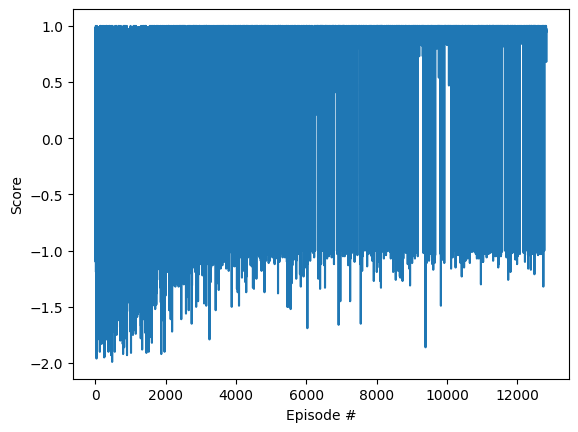

In [19]:
# plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()

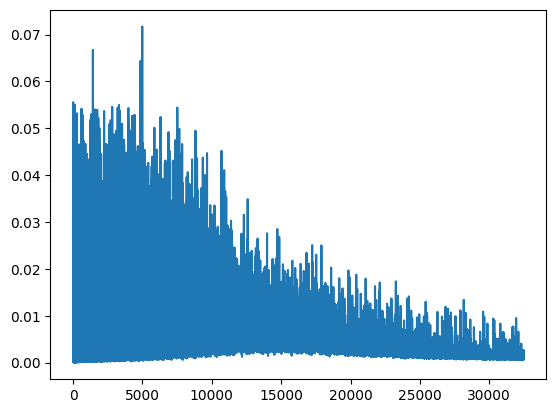

In [20]:
plt.plot(agent.losses)
plt.show()

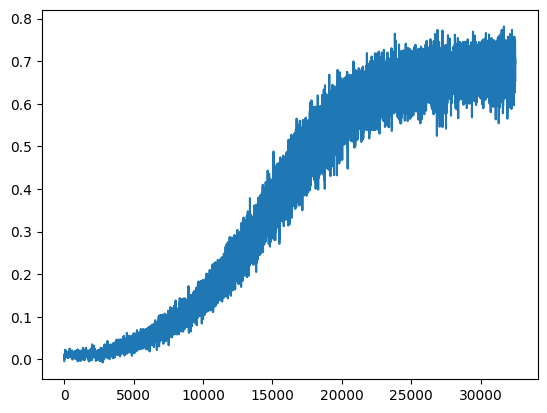

In [21]:
plt.plot(agent.q_log)
plt.show()

In [22]:
q = np.array(agent.q_log); l = np.array(agent.losses)
print("Q  first/last 1k:", q[:1000].mean(), q[-1000:].mean(), "min/max:", q.min(), q.max())
print("loss first/last 1k:", l[:1000].mean(), l[-1000:].mean())

Q  first/last 1k: 0.010620691730931867 0.692776071369648 min/max: -0.007390178740024567 0.7815099358558655
loss first/last 1k: 0.01712619275189718 0.0012592306676669977


### Reading these numbers

Mean Q ends at **0.693** with a maximum of **0.782**, against a mean discounted return
of **0.622** and an environment ceiling of **0.99**. The value function is calibrated
and stays under the bound throughout.

For reference, a correct Q at gamma 0.9 by distance to the correct target:

| distance | true Q |
|---|---|
| 1 step | 0.990 |
| 2 | 0.881 |
| 3 | 0.783 |
| 4 | 0.695 |

A buffer whose states sit mostly 2–4 steps out has a true mean near 0.79, so 0.693
over a mix that also includes exploratory actions and earlier, worse policy is in the
right range.

The falling loss (0.017 to 0.0013) means little on its own — the diverged gamma 0.99
run reached a *lower* loss of 0.00085 while its Q-values climbed past the ceiling. Low
TD error only says the network is self-consistent, not that it is right.

## Final greedy evaluation

Two evaluations were run: 50 episodes inside the training loop (0.935) and 20 episodes
below (0.9705). Both are near-optimal, but they carry different amounts of evidence.

Working backwards from the means, the 20-episode run contained **zero failures** — a
single wrong target would cap the mean at 0.89, since one -1 cannot be offset by
nineteen +0.99s. The 50-episode run at 0.935 is consistent with exactly **one**
failure.

Once failures are this rare the usual `mean ± 1.96·SE` interval stops applying: it
needs enough of both outcomes in the sample, and with zero observed failures the
normal approximation has nothing to work with (it would return an interval extending
above +1, an impossible return). The right tool is a binomial bound:

| result | 95% upper bound on failure rate |
|---|---|
| 0 failures in 20 | 13.9% |
| 1 failure in 50 | 9.1% |   
| 0 failures in 50 | 5.8% |
| 0 failures in 100 | 3.0% |


for 1 in 50 failure: **P(X ≤ 1) = P(X=0) + P(X=1) = (1−q)⁵⁰ + 50·q·(1−q)⁴⁹**

So a clean 20-episode run is still consistent with a policy that fails one time in
seven. For a headline number, 100 episodes is the honest sample size — a couple of
extra minutes of simulation.

In [21]:
#trained agent
#back to normal speed
channel.set_configuration_parameters(time_scale=1.0)
all_rewards = []
for episode in range(20):
  env.reset()
  decision_steps, terminal_steps = env.get_steps(behavior_name)
  tracked_agent = -1 # -1 indicates not yet tracking
  done = False # For the tracked_agent
  episode_rewards = 0 # For the tracked_agent
  while not done:
    # Track the first agent we see if not tracking
    # Note : len(decision_steps) = [number of agents that requested a decision]
    if tracked_agent == -1 and len(decision_steps) >= 1:
      tracked_agent = decision_steps.agent_id[0]

    # Generate an action for all agents
    decision_mask = decision_steps.action_mask[0] if decision_steps.action_mask is not None else np.zeros((len(decision_steps), action_size), dtype=bool)
    actions = agent.act(decision_steps.obs[0], decision_steps.obs[1],decision_mask)

    # Set the actions
    env.set_actions(behavior_name, ActionTuple(discrete=actions.reshape(-1, 1).astype(np.int32)))

    # Move the simulation forward
    env.step()

    # Get the new simulation results
    decision_steps, terminal_steps = env.get_steps(behavior_name)
    if tracked_agent in decision_steps: # The agent requested a decision
      episode_rewards += decision_steps[tracked_agent].reward
    if tracked_agent in terminal_steps: # The agent terminated its episode
      episode_rewards += terminal_steps[tracked_agent].reward
      done = True
      all_rewards.append(episode_rewards)
      print(f"\rTotal rewards for episode {episode} is {episode_rewards:.4f}", end="")

print(f"\nAverage rewards over 20 episodes is {np.mean(all_rewards):.4f}")


Total rewards for episode 19 is 0.9700
Average rewards over 20 episodes is 0.9705
